In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def euler_forward(f, y0, t0, t_end, dt):
    t = np.arange(t0, t_end + dt, dt)
    y = np.zeros_like(t)
    y[0] = y0
    for i in range(1, len(t)):
        y[i] = y[i-1] + dt * f(y[i-1])
    return t, y

# Persamaan dan solusi eksak
f = lambda y: -2*y
y_exact_func = lambda t: np.exp(-2*t)


Δt = 0.1, Galat di t=1: 0.206606
       t      y_eksak    y_numerik        galat
-----------------------------------------------
   0.000     1.000000     1.000000     0.000000
   0.100     0.818731     0.800000     0.022878
   0.200     0.670320     0.640000     0.045232
   0.300     0.548812     0.512000     0.067075
   0.400     0.449329     0.409600     0.088418
   0.500     0.367879     0.327680     0.109273
   0.600     0.301194     0.262144     0.129651
   0.700     0.246597     0.209715     0.149563
   0.800     0.201897     0.167772     0.169019
   0.900     0.165299     0.134218     0.188030
   1.000     0.135335     0.107374     0.206606


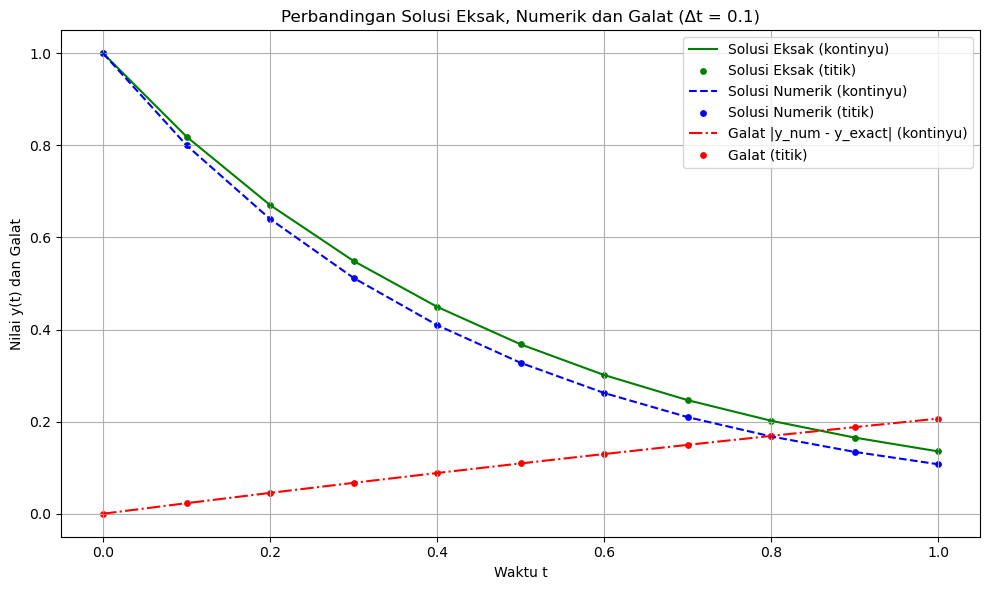


Δt = 0.01, Galat di t=1: 0.020067
       t      y_eksak    y_numerik        galat
-----------------------------------------------
   0.000     1.000000     1.000000     0.000000
   0.010     0.980199     0.980000     0.000203
   0.020     0.960789     0.960400     0.000405
   0.030     0.941765     0.941192     0.000608
   0.040     0.923116     0.922368     0.000811
   0.050     0.904837     0.903921     0.001013
   0.060     0.886920     0.885842     0.001216
   0.070     0.869358     0.868126     0.001418
   0.080     0.852144     0.850763     0.001620
   0.090     0.835270     0.833748     0.001823
   0.100     0.818731     0.817073     0.002025
   0.110     0.802519     0.800731     0.002227
   0.120     0.786628     0.784717     0.002430
   0.130     0.771052     0.769022     0.002632
   0.140     0.755784     0.753642     0.002834
   0.150     0.740818     0.738569     0.003036
   0.160     0.726149     0.723798     0.003238
   0.170     0.711770     0.709322     0.003440
   0.

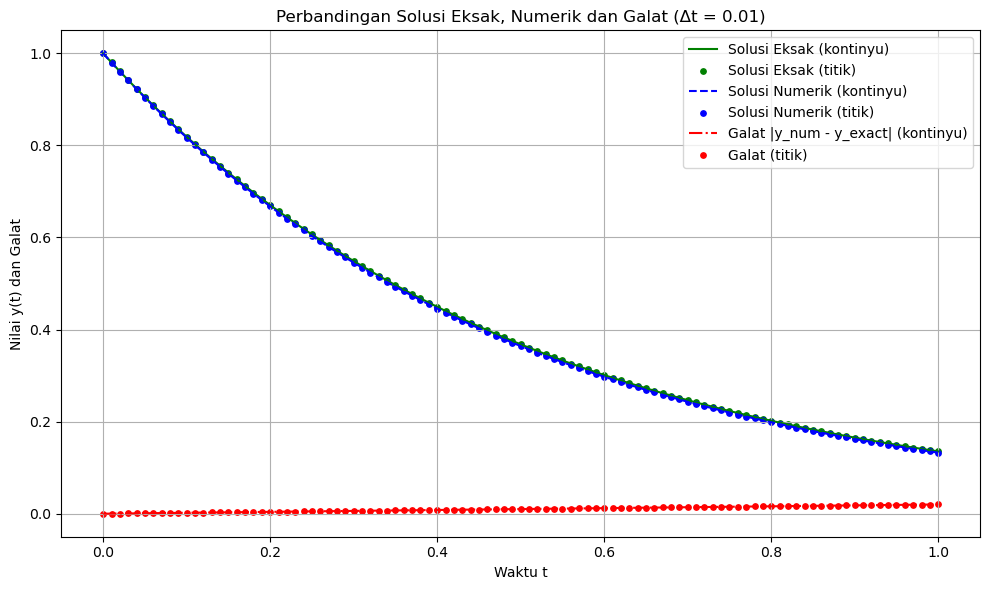


Δt = 0.001, Galat di t=1: 0.002001
       t      y_eksak    y_numerik        galat
-----------------------------------------------
   0.000     1.000000     1.000000     0.000000
   0.001     0.998002     0.998000     0.000002
   0.002     0.996008     0.996004     0.000004
   0.003     0.994018     0.994012     0.000006
   0.004     0.992032     0.992024     0.000008
   0.005     0.990050     0.990040     0.000010
   0.006     0.988072     0.988060     0.000012
   0.007     0.986098     0.986084     0.000014
   0.008     0.984127     0.984112     0.000016
   0.009     0.982161     0.982143     0.000018
   0.010     0.980199     0.980179     0.000020
   0.011     0.978240     0.978219     0.000022
   0.012     0.976286     0.976262     0.000024
   0.013     0.974335     0.974310     0.000026
   0.014     0.972388     0.972361     0.000028
   0.015     0.970446     0.970416     0.000030
   0.016     0.968507     0.968476     0.000032
   0.017     0.966572     0.966539     0.000034
   0

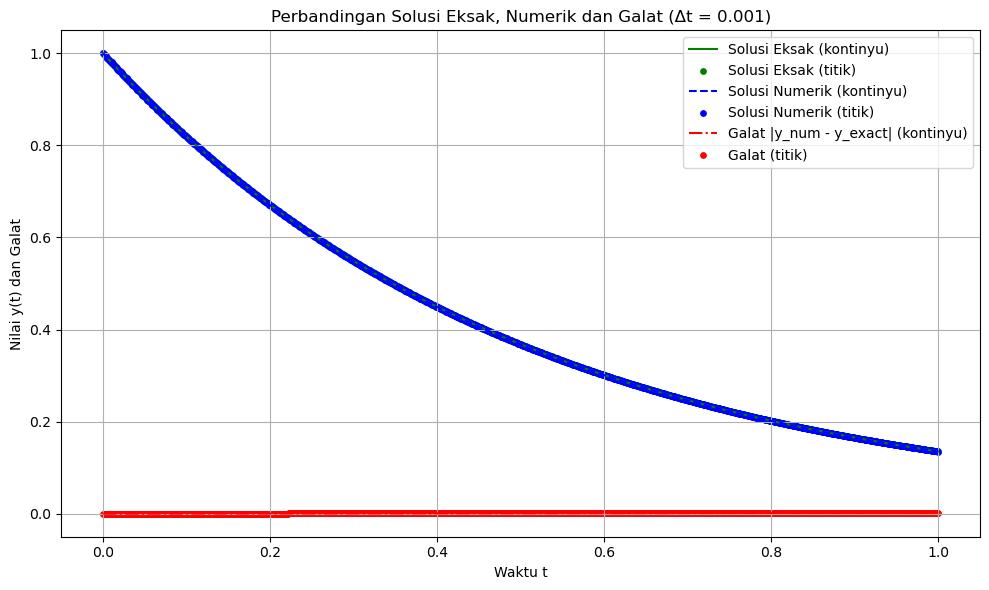

In [ ]:
def midpoint(f, y0, t0, t_end, dt):
    t = np.arange(t0, t_end + dt, dt)
    y = np.zeros_like(t)
    y[0] = y0
    for i in range(1, len(t)):
        k1 = f(y[i-1])
        y_mid = y[i-1] + 0.5 * dt * k1
        k2 = f(y_mid)
        y[i] = y[i-1] + dt * k2
    return t, y

# Pilihan Δt untuk perbandingan
dt_values = [0.1, 0.01, 0.001]

for dt in dt_values:
    t, y_euler = euler_forward(f, 1, 0, 1, dt)
    _, y_mid = midpoint(f, 1, 0, 1, dt)
    y_exact = y_exact_func(t)

    err_euler = np.abs(y_euler - y_exact) / np.abs(y_exact)
    err_mid = np.abs(y_mid - y_exact) / np.abs(y_exact)

    # Cetak ringkasan galat pada t=1
    print(f"\nΔt = {dt}")
    print(f"Galat di t=1: Euler = {err_euler[-1]:.6e}, Midpoint = {err_mid[-1]:.6e}")

    # Cetak tabel data
    print(f"{'t':>8} {'y_eksak':>12} {'y_euler':>12} {'y_mid':>12} {'galat_euler':>12} {'galat_mid':>12}")
    print("-" * 80)
    for i in range(len(t)):
        print(f"{t[i]:8.3f} {y_exact[i]:12.6f} {y_euler[i]:12.6f} {y_mid[i]:12.6f} {err_euler[i]:12.6f} {err_mid[i]:12.6f}")

    # Plot perbandingan solusi dan galat
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 1, 1)
    plt.plot(t, y_exact, 'g-', label='Solusi Eksak')
    plt.plot(t, y_euler, 'b--', label='Euler Forward')
    plt.plot(t, y_mid, 'm-.', label='Midpoint')
    plt.title(f'Perbandingan Solusi (Δt = {dt})')
    plt.ylabel('y(t)')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(t, err_euler, 'b--', label='Galat Euler')
    plt.plot(t, err_mid, 'm-.', label='Galat Midpoint')
    plt.yscale('log')
    plt.xlabel('Waktu t')
    plt.ylabel('Galat relatif')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()